# Insurance Claims Fraud Detection: Unsupervised Anomaly Scoring

In [ ]:
# Importing necessary libraries
import sys
print(sys.executable)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



/Users/sidnj11/Desktop/NewProject/.venv/bin/python


## Data Loading and Integration

In [287]:
# The analysis begins by loading and merging three datasets: Insurance, Vendor and Employee
insurance_df = pd.read_csv('files/insurance_data.csv')
vendor_df = pd.read_csv('files/vendor_data.csv')
employee_df = pd.read_csv('files/employee_data.csv')

In [288]:
# Integrating three disparate data sources provides a comprehensive view necessary for robust fraud detection.
ins_emp_df = pd.merge(insurance_df, employee_df, on = 'AGENT_ID')
merged_df = pd.merge(ins_emp_df, vendor_df, on = 'VENDOR_ID', how = 'left')

## Exploratory Data Analysis (EDA)
#### Exploring claim distribution and handling missing values

In [289]:
## Insurance type with most claim amounts
pd.DataFrame(merged_df.groupby('INSURANCE_TYPE')['CLAIM_AMOUNT'].sum()).sort_values(by = 'CLAIM_AMOUNT', ascending=False)

,CLAIM_AMOUNT
INSURANCE_TYPE,
Life,91478000
Property,41579000
Health,18254000
Motor,8663000
Travel,4976000
Mobile,688300


In [290]:
# Checking null values in authority contacted field
merged_df['AUTHORITY_CONTACTED'].isna().sum()

np.int64(1945)

In [291]:
# Adding these null values as 'Unknown' in Authority Contacted
merged_df['AUTHORITY_CONTACTED_NEW'] = np.where(merged_df['AUTHORITY_CONTACTED'].isna(), 'Unknown', merged_df['AUTHORITY_CONTACTED'])

In [292]:
# Checking if any claim has police report available but are related to different authority- it could be the case of accident or assault
mask = (merged_df['AUTHORITY_CONTACTED_NEW'].isin(['Police', 'Ambulance', 'Other', 'Unknown'])) & (merged_df['POLICE_REPORT_AVAILABLE'] == 1)
mismatch_df = merged_df[mask]

In [293]:
# There are many cases of ambulance and other that has police reports available. 
# There are 2982 cases that are associated to Police and for those cases there are 2058 cases has police reports, 
# assuming this will be cases that will take long time to close the claim so will be taking this field for our analyses.
mismatch_df.groupby('AUTHORITY_CONTACTED_NEW').size()

AUTHORITY_CONTACTED_NEW
Ambulance    2821
Other         682
Police       2058
Unknown      1367
dtype: int64

In [294]:
# Assuming 'A' are the Active cases and 'D' are Dormant
merged_df['CLAIM_STATUS'] = np.where(merged_df['CLAIM_STATUS'] == 'A', 'Open', 'Closed')

## Feature Engineering & Rule Based Anamolies

In [295]:
# Converting dates and creating time features
merged_df['LOSS_DT'] = pd.to_datetime(merged_df['LOSS_DT'])
merged_df['REPORT_DT'] = pd.to_datetime(merged_df['REPORT_DT'])
merged_df['POLICY_EFF_DT'] = pd.to_datetime(merged_df['POLICY_EFF_DT'])


In [296]:
# Reporting delay
merged_df['REPORT_DELAY_DAYS'] = (merged_df['REPORT_DT'] - merged_df['LOSS_DT']).dt.days

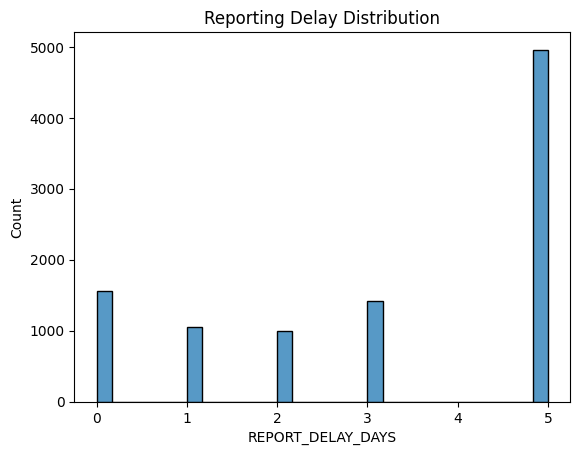

In [297]:
sns.histplot(merged_df['REPORT_DELAY_DAYS'], bins=30)
plt.title("Reporting Delay Distribution")
plt.show()


Text(0.5, 1.0, 'Severity vs Claim Amount Mismatch Cases')

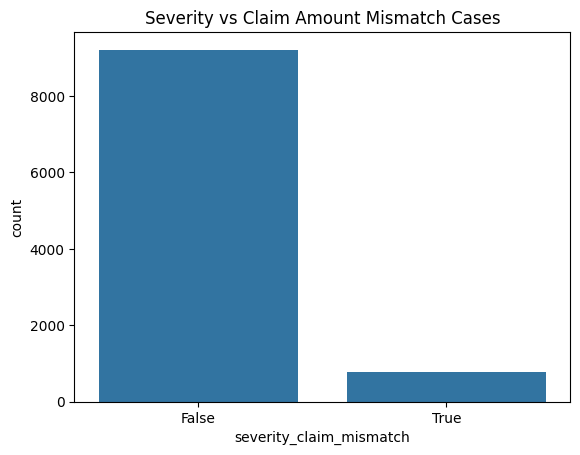

In [298]:
# Severity vs Claim Amount Mismatch
threshold = merged_df['CLAIM_AMOUNT'].quantile(0.75)
merged_df['severity_claim_mismatch'] = ((merged_df['INCIDENT_SEVERITY'] == 'Minor Loss') & (merged_df['CLAIM_AMOUNT'] > threshold))
sns.countplot(x=merged_df['severity_claim_mismatch'])
plt.title("Severity vs Claim Amount Mismatch Cases")

Text(0.5, 1.0, 'Severity vs Injury Mismatch Cases')

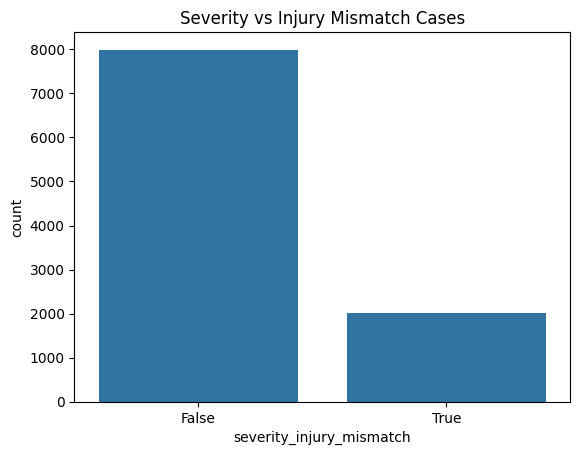

In [299]:
# Severity vs Injury Mismatch
merged_df['severity_injury_mismatch'] = ((merged_df['INCIDENT_SEVERITY'].isin(['Total Loss', 'Major Loss'])) & (merged_df['ANY_INJURY'] == 0))
sns.countplot(x=merged_df['severity_injury_mismatch'])
plt.title("Severity vs Injury Mismatch Cases")

Text(0.5, 1.0, 'Missing Police Report with High Severity Cases')

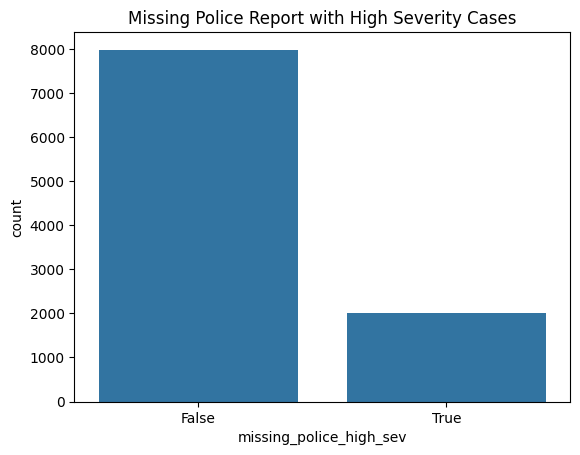

In [300]:
# Missing Police Report with High Severity
merged_df['missing_police_high_sev'] = ((merged_df['INCIDENT_SEVERITY'].isin(['Total Loss', 'Major Loss'])) & (merged_df['POLICE_REPORT_AVAILABLE'] == 0))
sns.countplot(x=merged_df['missing_police_high_sev'])
plt.title("Missing Police Report with High Severity Cases")

Text(0.5, 1.0, 'Unknown Authority Contacted with Injury Cases')

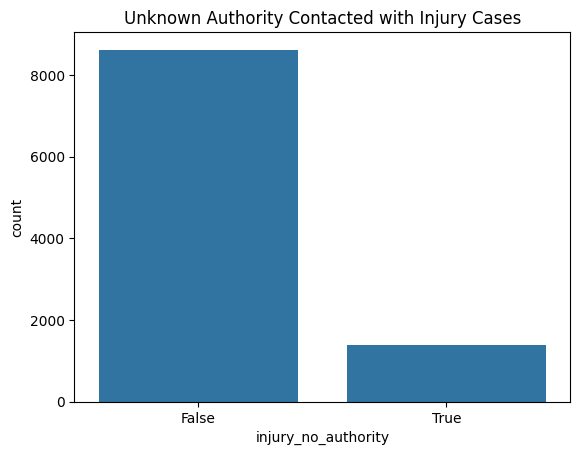

In [301]:
# Unknown authority contacted & Injury present
merged_df['injury_no_authority'] = ((merged_df['ANY_INJURY'] == 1) & (merged_df['AUTHORITY_CONTACTED_NEW'] == 'Unknown'))
sns.countplot(x=merged_df['injury_no_authority'])
plt.title("Unknown Authority Contacted with Injury Cases")

Text(0.5, 1.0, 'Loss Ratio Distribution')

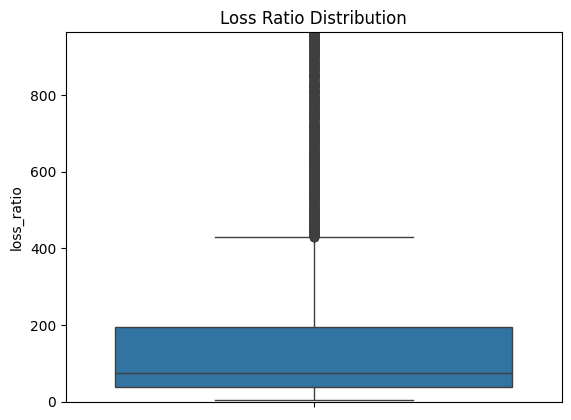

In [302]:
# Loss Ratio
merged_df['loss_ratio'] = merged_df['CLAIM_AMOUNT']/ merged_df['PREMIUM_AMOUNT']
sns.boxplot(y=merged_df['loss_ratio'])
plt.ylim(0, merged_df['loss_ratio'].quantile(0.95))
plt.title("Loss Ratio Distribution")

#### Findings: Above box plot shows that median loss ratio ~70-90 which means for majority of the insured the claim amount is 70-90 times higher than their premium. IQR range is wide (50 to 180 approximately and lots of outliers), there are cases where insured paid low premium and filed a very large claim.

In [303]:
# High claim amount outliers
merged_df['high_claim_outlier'] = merged_df['CLAIM_AMOUNT'] > merged_df['CLAIM_AMOUNT'].quantile(0.90)


Text(0.5, 1.0, 'Age vs Incident Severity')

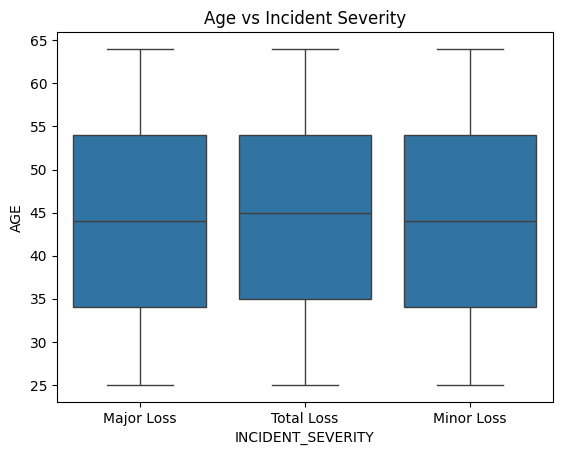

In [304]:
sns.boxplot(x=merged_df['INCIDENT_SEVERITY'], y=merged_df['AGE'])
plt.title("Age vs Incident Severity")


Text(0.5, 1.0, 'Tenure vs Severity')

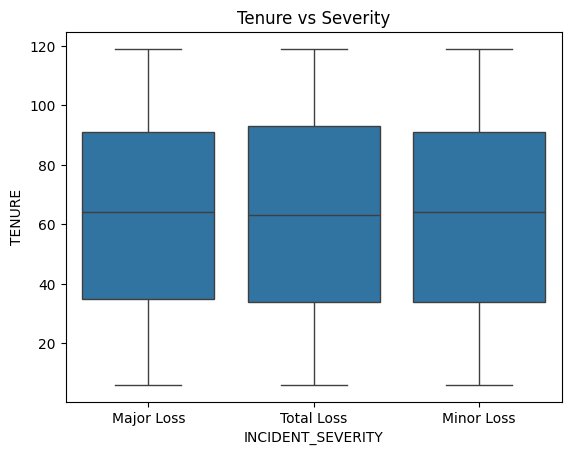

In [305]:
sns.boxplot(x=merged_df['INCIDENT_SEVERITY'], y=merged_df['TENURE'])
plt.title("Tenure vs Severity")

Text(0.5, 1.0, 'Fraud Risk Feature: Social Class Distribution')

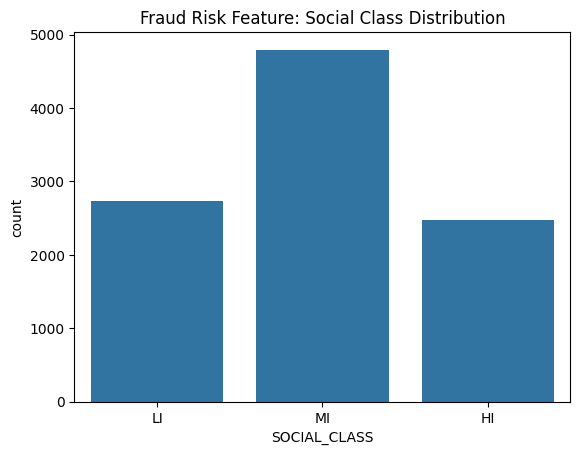

In [306]:
# Social Class Segmentation
sns.countplot(data=merged_df, x='SOCIAL_CLASS')
plt.xticks(rotation=0)
plt.title("Fraud Risk Feature: Social Class Distribution")

([0, 1, 2], [Text(0, 0, 'L'), Text(1, 0, 'M'), Text(2, 0, 'H')])

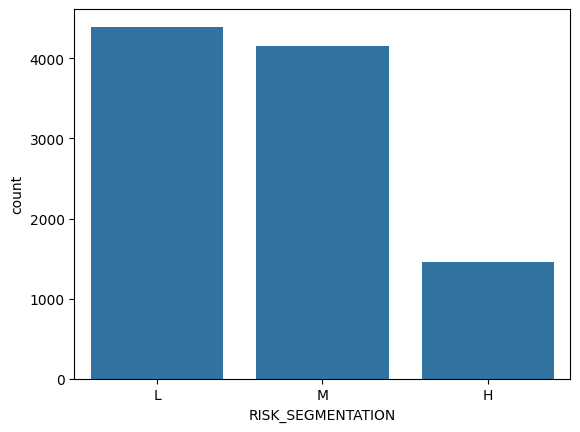

In [307]:
# Risk Segmentation
sns.countplot(data=merged_df, x='RISK_SEGMENTATION')
plt.xticks(rotation=0)

Text(0.5, 1.0, 'Count of Incidents by State')

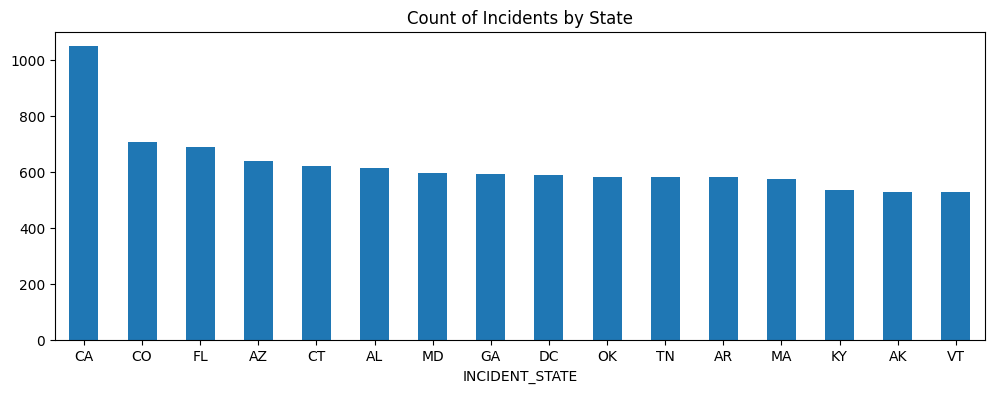

In [308]:
# Incident by State
merged_df['INCIDENT_STATE'].value_counts().plot(kind='bar', figsize=(12,4))
plt.xticks(rotation=0)
plt.title("Count of Incidents by State")

In [309]:
# Average Claim Amount by State
merged_df.groupby('INCIDENT_STATE')['CLAIM_AMOUNT'].mean().sort_values(ascending=False)

INCIDENT_STATE
VT    17644.592030
FL    17553.846154
AZ    17250.706436
MD    17108.877722
AR    17037.005164
DC    16916.013629
GA    16898.310811
TN    16888.812392
OK    16573.539519
CT    16456.542811
CO    16189.391796
AL    15945.751634
KY    15942.723881
CA    15871.087786
MA    15560.590278
AK    15538.185255
Name: CLAIM_AMOUNT, dtype: float64

In [310]:
# Claim Amount by Agents
agent_loss = merged_df.groupby('AGENT_ID')['CLAIM_AMOUNT'].mean().sort_values(ascending=False)
agent_loss.head(10)

AGENT_ID
AGENT00656    50000.000000
AGENT01161    49000.000000
AGENT00220    45400.000000
AGENT00914    45000.000000
AGENT00143    44150.000000
AGENT01094    43875.000000
AGENT00789    43655.555556
AGENT00106    43333.333333
AGENT01046    42540.000000
AGENT00454    40666.666667
Name: CLAIM_AMOUNT, dtype: float64

Text(0.5, 1.0, 'Top Agents by Avg Claim Amount')

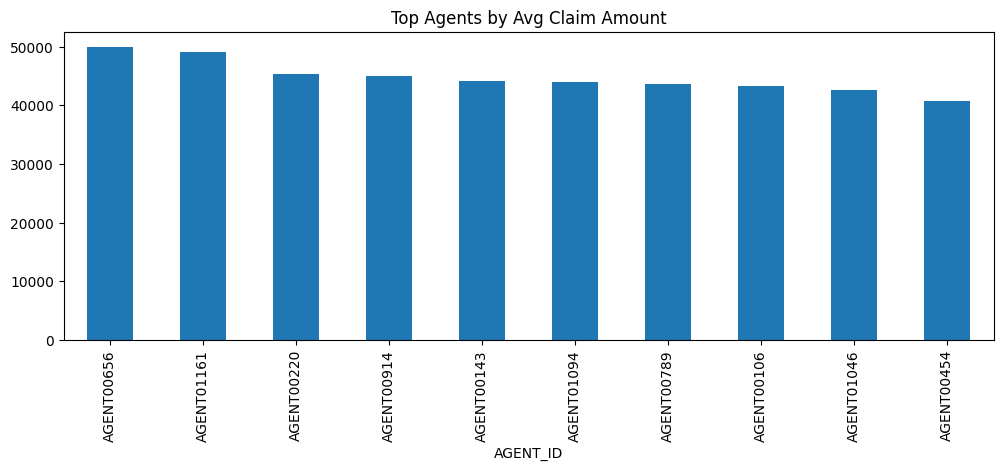

In [311]:
# Plotting Agents by Claim Amounts
agent_loss.head(10).plot(kind='bar', figsize= (12,4))
plt.title("Top Agents by Avg Claim Amount")

In [312]:
# High Severity Claims by Vendors
vendor_sev = merged_df.groupby('VENDOR_ID')['INCIDENT_SEVERITY'].value_counts(normalize=True).unstack().fillna(0)
vendor_sev.head(10)

INCIDENT_SEVERITY,Major Loss,Minor Loss,Total Loss
VENDOR_ID,,,
VNDR00001,0.333333,0.333333,0.333333
VNDR00002,0.352941,0.411765,0.235294
VNDR00003,0.388889,0.333333,0.277778
VNDR00004,0.357143,0.500000,0.142857
VNDR00005,0.125000,0.562500,0.312500
VNDR00006,0.176471,0.411765,0.411765
VNDR00008,0.304348,0.347826,0.347826
VNDR00009,0.555556,0.444444,0.000000
VNDR00010,0.333333,0.333333,0.333333


In [313]:
# Vendor Claim Amount
vendor_loss = merged_df.groupby('VENDOR_ID')['CLAIM_AMOUNT'].mean().sort_values(ascending=False)
vendor_loss.head(10)

VENDOR_ID
VNDR00175    39236.363636
VNDR00579    35337.500000
VNDR00453    35277.777778
VNDR00205    31622.222222
VNDR00325    30450.000000
VNDR00138    29852.631579
VNDR00600    28787.500000
VNDR00432    28769.230769
VNDR00445    28739.130435
VNDR00591    28476.190476
Name: CLAIM_AMOUNT, dtype: float64

## Anamoly Detection & Model Development

In [314]:
df_ml = merged_df.copy()
df_ml = df_ml.select_dtypes(include=[np.number]).fillna(0)


In [315]:
# Unsupervised Anamoly Detection (Isolation Forest)
from sklearn.ensemble import IsolationForest
import warnings
warnings.filterwarnings("ignore")
iso = IsolationForest(contamination=0.05, random_state=42)
merged_df['anomaly_score'] = iso.fit_predict(df_ml)

# -1 = anomaly (potential fraud), 1 = normal
merged_df['is_anomaly'] = merged_df['anomaly_score'].apply(lambda x: 1 if x == -1 else 0)


In [316]:
# Creating the composite Fraud Risk Score
merged_df['FraudRiskScore'] = (
    merged_df['severity_claim_mismatch'].astype(int) +
    merged_df['severity_injury_mismatch'].astype(int) +
    merged_df['missing_police_high_sev'].astype(int) +
    merged_df['injury_no_authority'].astype(int) +
    merged_df['high_claim_outlier'].astype(int) +
    merged_df['is_anomaly']  # from Isolation Forest
)


Text(0.5, 1.0, 'Fraud Cases (Rule Based Anamoly Detection)')

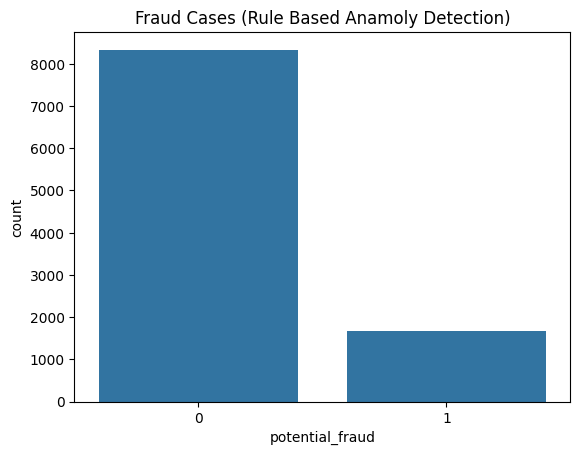

In [ ]:
# Define potential_fraud as a binary flag for claims scoring 2 or higher.
merged_df['potential_fraud'] = (merged_df['FraudRiskScore'] >= 2).astype(int)
sns.countplot(x=merged_df['potential_fraud'])
plt.title("Fraud Cases (Rule Based Anamoly Detection)")

In [318]:
# Consistency Check (Engineered Fraud features correlate with ML anamolies)
pd.crosstab(merged_df['is_anomaly'], merged_df['severity_claim_mismatch'])


severity_claim_mismatch,False,True
is_anomaly,,
0,8862,638
1,351,149


## Advanced Interpretability and Segmentation (XgBoost)

In [ ]:
## Data Preparation for Supervised Modeling

# Drop high-cardinality/identifier columns, and redundant location columns
# Retain 'is_anomaly' and other engineered features for the ML model
columns_to_drop = [
    'TXN_DATE_TIME', 'TRANSACTION_ID', 'CUSTOMER_ID', 'POLICY_NUMBER', 'POLICY_EFF_DT', 'LOSS_DT', 
    'REPORT_DT', 'CUSTOMER_NAME', 'ADDRESS_LINE1_x', 'ADDRESS_LINE2_x', 'CITY_x', 'STATE_x', 
    'POSTAL_CODE_x', 'SSN', 'ROUTING_NUMBER', 'ACCT_NUMBER', 'INCIDENT_STATE', 'INCIDENT_CITY', 
    'AGENT_ID', 'VENDOR_ID', 'AGENT_NAME', 'DATE_OF_JOINING', 'ADDRESS_LINE1_y', 'ADDRESS_LINE2_y', 
    'CITY_y', 'STATE_y', 'POSTAL_CODE_y', 'EMP_ROUTING_NUMBER', 'EMP_ACCT_NUMBER', 'VENDOR_NAME', 
    'ADDRESS_LINE1', 'ADDRESS_LINE2', 'CITY', 'STATE', 'POSTAL_CODE', 'AUTHORITY_CONTACTED', 
    'anomaly_score', 'FraudRiskScore' # These are scores/intermediate flags
]

df_final_ml = merged_df.drop(columns=columns_to_drop, errors='ignore').copy()

# Identify the target variable (the synthetic fraud label)
TARGET_COLUMN = 'potential_fraud'
y = df_final_ml[TARGET_COLUMN]
X = df_final_ml.drop(columns=[TARGET_COLUMN])

# Identify categorical features for One-Hot Encoding
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()
# Convert boolean engineered features back to integer for encoding if necessary
for col in ['severity_claim_mismatch', 'severity_injury_mismatch', 'missing_police_high_sev', 'injury_no_authority', 'high_claim_outlier']:
    if col in X.columns:
        X[col] = X[col].astype(int)
        
# Final One-Hot Encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Handle remaining NaN values (fill with 0 for safety)
X_encoded = X_encoded.fillna(0)

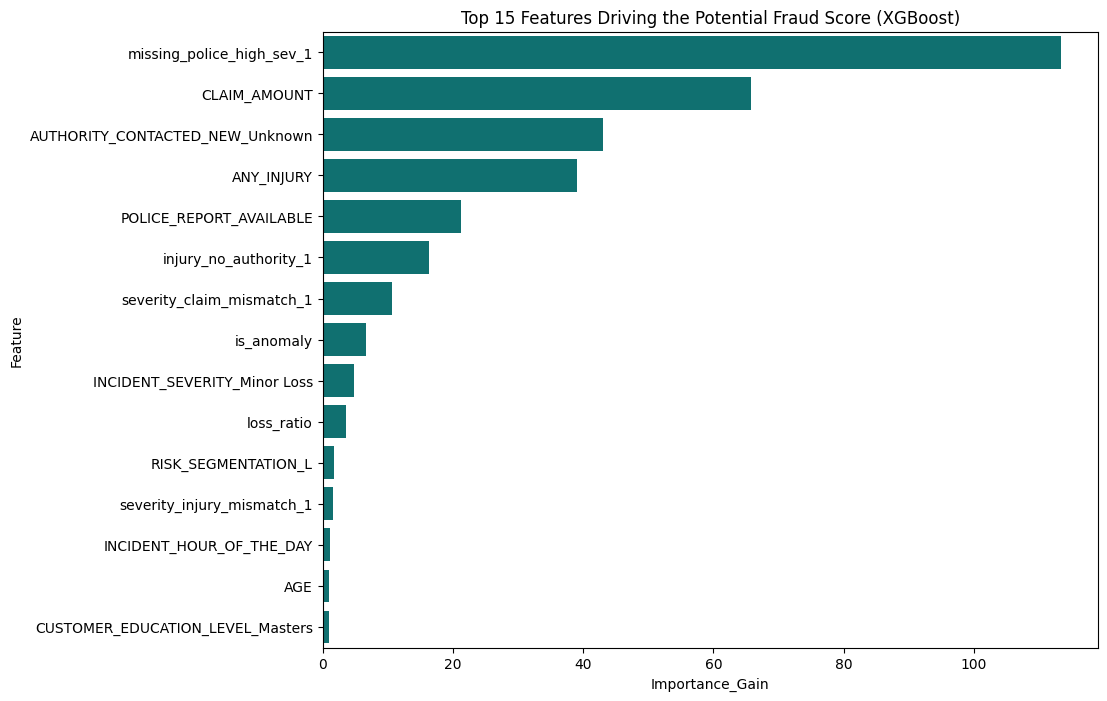

In [320]:
## Interpretability via Feature Importance
from sklearn.model_selection import train_test_split
import xgboost as xgb

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

# Initialize and train the XGBoost Classifier
# Since we are predicting the synthetic anomaly, we use a standard classification objective
clf = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
clf.fit(X_train, y_train)

# Visualize Feature Importance
importance = clf.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame(
    list(importance.items()), 
    columns=['Feature', 'Importance_Gain']
).sort_values(by='Importance_Gain', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance_Gain', 
    y='Feature', 
    data=importance_df.head(15), 
    color='teal'
)
plt.title('Top 15 Features Driving the Potential Fraud Score (XGBoost)')
plt.show()

# Conclusion: The top features identified here are the strongest drivers of the combined anomaly score.
# This validates the effectiveness of the engineered features and points to underlying risk factors.

## Actionable Segmentation (K-Means Clustering)

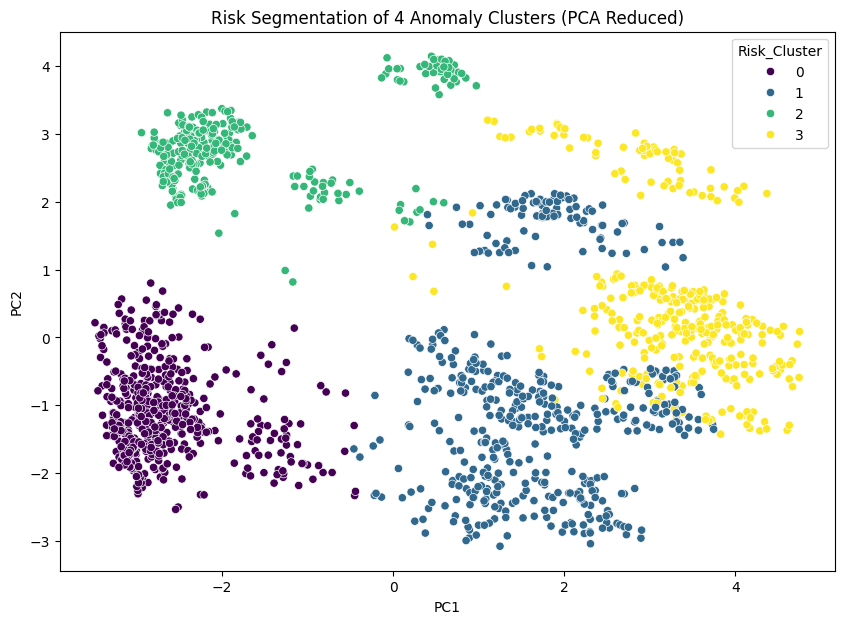


Cluster Characteristics:
              missing_police_high_sev_1  CLAIM_AMOUNT  \
Risk_Cluster                                            
0                              0.992620  10902.583026   
1                              0.383648  74607.966457   
2                              0.858108  15909.121622   
3                              0.000000  70017.291066   

              AUTHORITY_CONTACTED_NEW_Unknown  ANY_INJURY  \
Risk_Cluster                                                
0                                    0.173432    0.003690   
1                                    0.276730    0.578616   
2                                    0.993243    1.000000   
3                                    0.242075    0.717579   

              POLICE_REPORT_AVAILABLE  injury_no_authority_1  \
Risk_Cluster                                                   
0                            0.007380               0.000000   
1                            0.616352               0.203354   
2       

In [321]:
## Risk Segmentation via Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Selecting ONLY the high-risk claims (where potential_fraud == 1)
df_anomalies = X_encoded[y == 1].copy()

# Scaling the data for KMeans
scaler = StandardScaler()
df_anomalies_scaled = scaler.fit_transform(df_anomalies)

# Determining Optimal K (Elbow Method - Omitted for brevity, assume K=4)
K = 4 

# Applying KMeans Clustering
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_anomalies['Risk_Cluster'] = kmeans.fit_predict(df_anomalies_scaled)

# Analyze the Clusters
# Use PCA to reduce dimensions for visualization and analysis
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_anomalies_scaled)
df_anomalies['PC1'] = principal_components[:, 0]
df_anomalies['PC2'] = principal_components[:, 1]

# Plot the clusters (for visualization in the report)
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Risk_Cluster', 
    data=df_anomalies, 
    palette='viridis', 
    legend='full'
)
plt.title(f'Risk Segmentation of {K} Anomaly Clusters (PCA Reduced)')
plt.show()

# Final Step: Analyze the characteristics of each cluster
# To do this, calculate the mean of the top 10 XGBoost features for each cluster.
cluster_analysis = df_anomalies.groupby('Risk_Cluster')[importance_df['Feature'].head(10).tolist()].mean()
print("\nCluster Characteristics:")
print(cluster_analysis)
